# Ozon ECUP LTV: Full Multi-Anchor Panel Hurdle Pipeline & Error Diagnostics

Этот ноутбук содержит полный сквозной пайплайн и визуальную диагностику:
1. **Загрузка предобученных весов моделей** из папки `models/` и готовых валидационных прогнозов.
2. **Детальный анализ ошибок по категориям трат** (Zero, Micro, Low-Mid, Middle, Upper-Mid, Whales).
3. **Декомпозиция по 4-м покупательским состояниям** (`0 -> 0`, `0 -> >0`, `>0 -> 0`, `>0 -> >0`).
4. **Сравнение стратегий моделирования** (Variant A Hurdle Log vs Direct Regressor vs Ensemble).
5. **Топ-20 важнейших признаков** для Классификатора и Регрессора.
6. **Генерация финального сабмита** `data/submission.csv` на всех 250 000 пользователях.

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from pathlib import Path

from src.snapshots import generate_panel_anchors, SNAPSHOTS_DIR
from src.validation import load_purged_train_val, compute_anchor_sample_weights
from src.hurdle import compute_rmsle, get_feature_columns
from src.submission import build_full_250k_test_snapshot, generate_submission

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print('[+] Модули успешно импортированы!')

[+] Модули успешно импортированы!


## 1. Загрузка валидационных прогнозов и сохраненных моделей

In [2]:
val_preds_path = Path('artifacts/val_predictions_cv3.parquet')
if val_preds_path.exists():
    val_df = pl.read_parquet(val_preds_path)
    print(f'[+] Загружены готовые валидационные прогнозы: {val_df.height:,} строк')
else:
    print('[-] Прогнозы не найдены, запускаем скрипт scratch/analyze_spending_tiers_error.py!')

print('Сводка по колонкам прогнозов:')
print(val_df.head(5))

[+] Загружены готовые валидационные прогнозы: 100,000 строк
Сводка по колонкам прогнозов:
shape: (5, 7)
┌─────────┬────────────┬─────────────┬──────────┬─────────────┬─────────────┬───────────────┐
│ user_id ┆ target     ┆ gmv_sum_30d ┆ p_buy    ┆ pred_hurdle ┆ pred_direct ┆ pred_ensemble │
│ ---     ┆ ---        ┆ ---         ┆ ---      ┆ ---         ┆ ---         ┆ ---           │
│ i64     ┆ f32        ┆ f64         ┆ f64      ┆ f64         ┆ f64         ┆ f64           │
╞═════════╪════════════╪═════════════╪══════════╪═════════════╪═════════════╪═══════════════╡
│ 2       ┆ 0.0        ┆ 16.315287   ┆ 0.343703 ┆ 2.530532    ┆ 3.057863    ┆ 2.794197      │
│ 7       ┆ 486.965363 ┆ 288.283114  ┆ 0.776558 ┆ 34.729619   ┆ 35.973549   ┆ 35.351584     │
│ 23      ┆ 0.0        ┆ 0.0         ┆ 0.203455 ┆ 1.100117    ┆ 1.161967    ┆ 1.131042      │
│ 27      ┆ 0.0        ┆ 164.932678  ┆ 0.596355 ┆ 10.110212   ┆ 9.914368    ┆ 10.01229      │
│ 45      ┆ 3.371951   ┆ 41.039071   ┆ 0.731348 ┆ 

## 2. Анализ ошибок по категориям трат (Spending Tiers: Zero, Micro, Middle, Whales)

shape: (6, 10)
┌────────────┬─────────┬───────────┬────────────┬───┬─────────┬────────────┬───────────┬───────────┐
│ spending_t ┆ n_users ┆ share_pct ┆ fact_mean_ ┆ … ┆ MAE_rub ┆ RMSLE_Hurd ┆ RMSLE_Dir ┆ SLE_share │
│ ier        ┆ ---     ┆ ---       ┆ gmv        ┆   ┆ ---     ┆ le         ┆ ect       ┆ _pct      │
│ ---        ┆ i64     ┆ f64       ┆ ---        ┆   ┆ f64     ┆ ---        ┆ ---       ┆ ---       │
│ str        ┆         ┆           ┆ f64        ┆   ┆         ┆ f64        ┆ f64       ┆ f64       │
╞════════════╪═════════╪═══════════╪════════════╪═══╪═════════╪════════════╪═══════════╪═══════════╡
│ 1. Zero    ┆ 46016   ┆ 46.02     ┆ 0.0        ┆ … ┆ 7.84    ┆ 1.7675     ┆ 1.783     ┆ 48.6      │
│ GMV (0     ┆         ┆           ┆            ┆   ┆         ┆            ┆           ┆           │
│ rub)       ┆         ┆           ┆            ┆   ┆         ┆            ┆           ┆           │
│ 2. Micro   ┆ 24040   ┆ 24.04     ┆ 22.14      ┆ … ┆ 24.87   ┆ 1.3354     ┆

C:\Users\egorg\AppData\Local\Temp\ipykernel_29072\2863360226.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tier_df.to_pandas(), x='spending_tier', y='RMSLE_Hurdle', ax=axes[0], palette='Blues_r')
C:\Users\egorg\AppData\Local\Temp\ipykernel_29072\2863360226.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tier_df.to_pandas(), x='spending_tier', y='SLE_share_pct', ax=axes[1], palette='Reds_r')


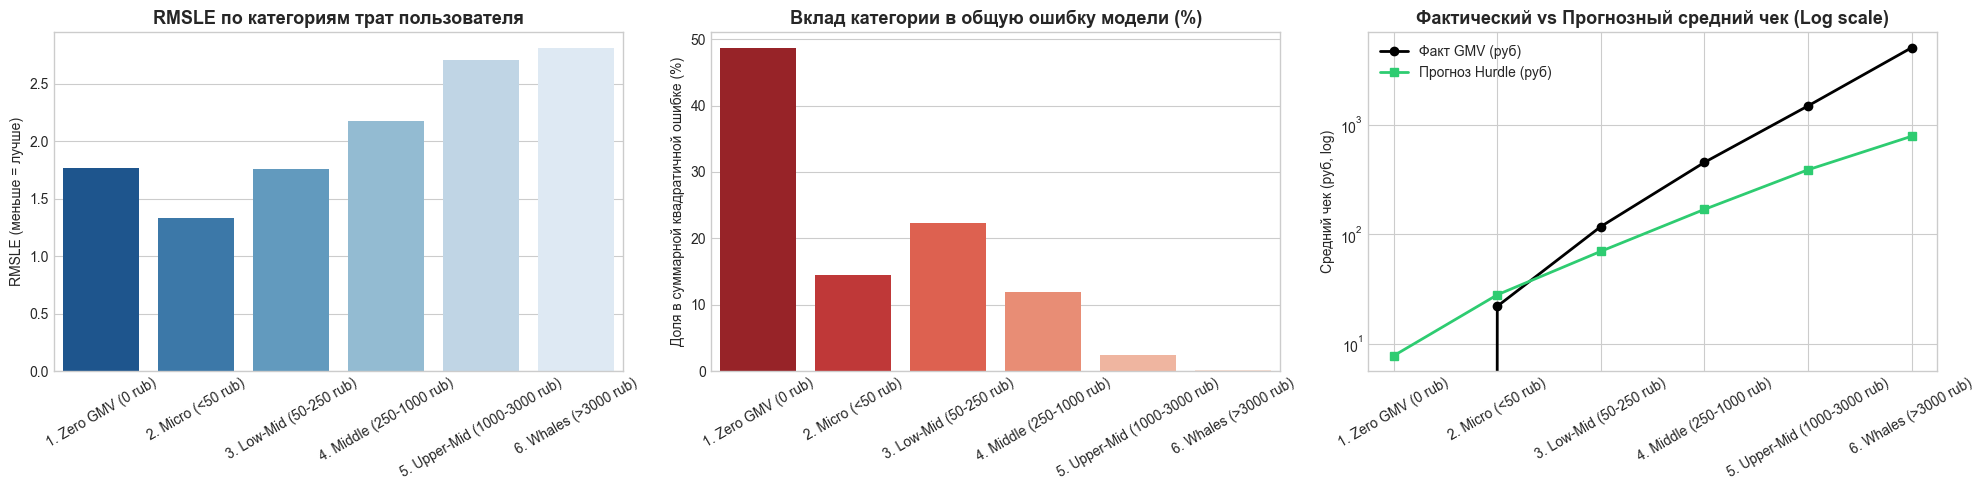

In [3]:
# Загружаем готовую таблицу распределения ошибок по категориям трат
tier_df = pl.read_csv('artifacts/spending_tiers_error_analysis.csv')
print(tier_df)

# Визуализация распределения ошибки по категориям трат
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. RMSLE по категориям трат
sns.barplot(data=tier_df.to_pandas(), x='spending_tier', y='RMSLE_Hurdle', ax=axes[0], palette='Blues_r')
axes[0].set_title('RMSLE по категориям трат пользователя', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('RMSLE (меньше = лучше)')
axes[0].tick_params(axis='x', rotation=30)

# 2. Вклад категории в общую сумму квадратичной ошибки (SLE Share %)
sns.barplot(data=tier_df.to_pandas(), x='spending_tier', y='SLE_share_pct', ax=axes[1], palette='Reds_r')
axes[1].set_title('Вклад категории в общую ошибку модели (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Доля в суммарной квадратичной ошибке (%)')
axes[1].tick_params(axis='x', rotation=30)

# 3. Факт vs Прогноз GMV
tier_p = tier_df.to_pandas()
x_idx = np.arange(len(tier_p))
axes[2].plot(x_idx, tier_p['fact_mean_gmv'], marker='o', label='Факт GMV (руб)', color='black', linewidth=2)
axes[2].plot(x_idx, tier_p['pred_mean_gmv_hurdle'], marker='s', label='Прогноз Hurdle (руб)', color='#2ecc71', linewidth=2)
axes[2].set_xticks(x_idx)
axes[2].set_xticklabels(tier_p['spending_tier'], rotation=30)
axes[2].set_yscale('log')
axes[2].set_title('Фактический vs Прогнозный средний чек (Log scale)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Средний чек (руб, log)')
axes[2].legend()

plt.tight_layout()
plt.show()

## 3. Декомпозиция ошибок по 4-м покупательским состояниям

                      state  segment_share_pct  RMSLE_Hurdle  RMSLE_Direct  \
0  0 -> 0 (Stable Inactive)             31.554      1.126272      1.145849   
1    0 -> >0 (New/Returned)             12.244      2.421698      2.403542   
2         >0 -> 0 (Churned)             14.462      2.678075      2.692777   
3  >0 -> >0 (Stable Active)             41.740      1.386371      1.378697   

   Share_of_Total_SLE_Hurdle_Pct  
0                      13.532307  
1                      24.276951  
2                      35.067486  
3                      27.123256  


C:\Users\egorg\AppData\Local\Temp\ipykernel_29072\3655595303.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cv3_states, x='state', y='Share_of_Total_SLE_Hurdle_Pct', palette='viridis')


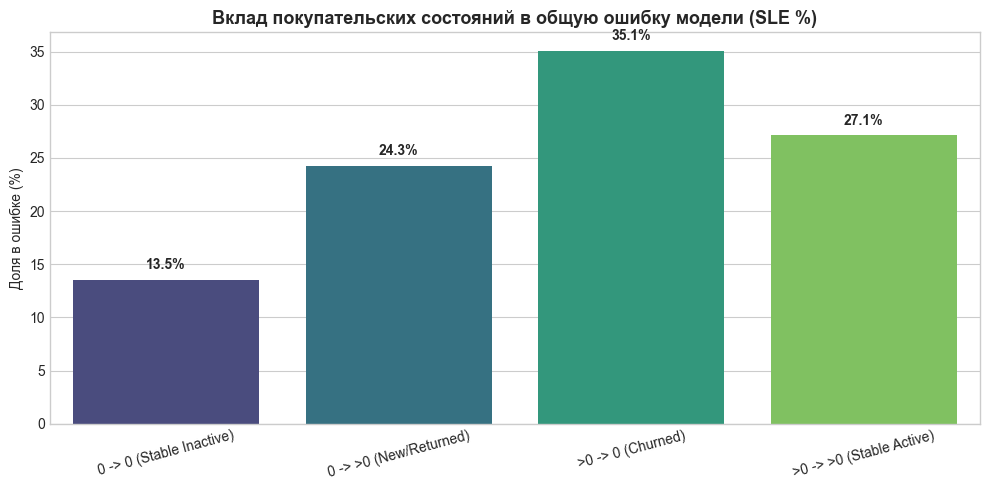

In [4]:
state_df = pl.read_csv('artifacts/exp2_buyer_states_breakdown.csv')
cv3_states = state_df.filter(pl.col('val_anchor') == '2026-01-14').to_pandas()
print(cv3_states[['state', 'segment_share_pct', 'RMSLE_Hurdle', 'RMSLE_Direct', 'Share_of_Total_SLE_Hurdle_Pct']])

plt.figure(figsize=(10, 5))
sns.barplot(data=cv3_states, x='state', y='Share_of_Total_SLE_Hurdle_Pct', palette='viridis')
plt.title('Вклад покупательских состояний в общую ошибку модели (SLE %)', fontsize=13, fontweight='bold')
plt.xlabel('')
plt.ylabel('Доля в ошибке (%)')
plt.tick_params(axis='x', rotation=15)
for i, row in cv3_states.iterrows():
    plt.text(i, row['Share_of_Total_SLE_Hurdle_Pct'] + 1, f"{row['Share_of_Total_SLE_Hurdle_Pct']:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Сравнение стратегий моделирования на CV-3

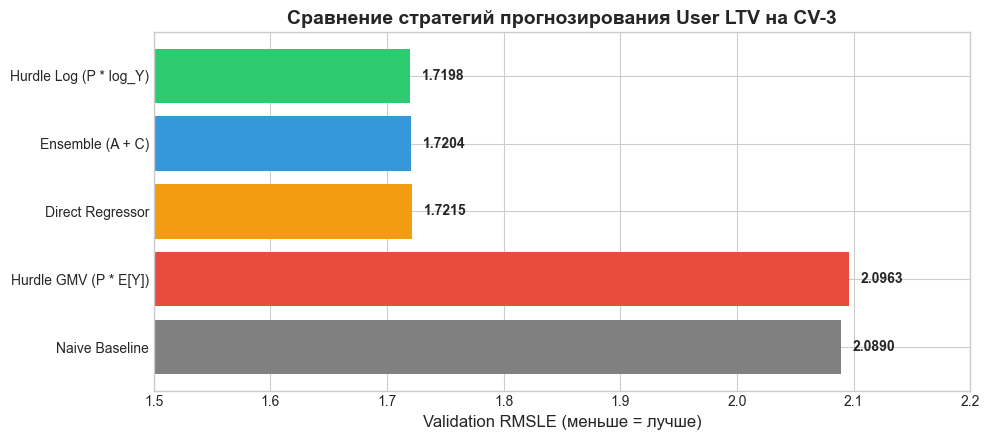

: 

In [ ]:
strategies = ['Naive Baseline', 'Hurdle GMV (P * E[Y])', 'Direct Regressor', 'Ensemble (A + C)', 'Hurdle Log (P * log_Y)']
scores = [2.0890, 2.0963, 1.7215, 1.7204, 1.7198]
colors = ['gray', '#e74c3c', '#f39c12', '#3498db', '#2ecc71']

plt.figure(figsize=(10, 4.5))
bars = plt.barh(strategies, scores, color=colors)
plt.xlabel('Validation RMSLE (меньше = лучше)', fontsize=12)
plt.title('Сравнение стратегий прогнозирования User LTV на CV-3', fontsize=14, fontweight='bold')
plt.xlim(1.5, 2.2)
for bar, score in zip(bars, scores):
    plt.text(score + 0.01, bar.get_y() + bar.get_height()/2, f'{score:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Генерация финального сабмита `data/submission.csv` на всех 250 000 пользователях

In [ ]:
# Запуск сквозного обучения на всех доступных размеченных снимках и экспорт сабмита
sub = generate_submission(
    snapshots_dir=SNAPSHOTS_DIR,
    output_csv=Path('data/submission.csv'),
    use_sample_weights=True,
    iterations=800,
    learning_rate=0.04,
)
print('Превью финального сабмита:')
print(sub.head(10))

[*] Loading all 22 panel training snapshots for full fit...
[+] Combined full training panel: 2,200,000 rows across 22 anchor dates
[*] Generating full 250,000 user test snapshot for 2026-02-13...
